# Modelo 04 — **image-only + balanceamento na origem** (célula que faltava do 2×2)

Combina os dois ingredientes que venceram nos experimentos anteriores:
- **Sem ramo clínico** (nb02 mostrou que os metadados degradavam a representação);
- **Balanceamento na imagem** (oversampling das minorias + augmentation no treino,
  como no nb03), em vez de SMOTE no espaço latente.

Completa o desenho fatorial 2×2 (clínico × balanceamento) e testa a hipótese de
que esta é a **melhor configuração**: descartar o metadado *e* balancear na origem.

**Idêntico aos demais:** mesmo split agrupado por `lesion_id` (mesma `SEED`, mesma
filtragem) → conjunto de **teste idêntico** → comparável aos nb 01/02/03.

**Saídas no Drive (`ICV_imageonly_balanced_grouped/`):** modelo + `imgfused` (256-d),
`gap` (1536-d), rótulos e `lesion_id` por split (imagens originais únicas).

In [1]:
!pip -q install albumentations opencv-python-headless kagglehub xgboost imbalanced-learn

In [2]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import cv2
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from keras import backend as K
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

IMG_SIZE  = (320, 320)
BATCH_SIZE = 32
AUTOTUNE  = tf.data.AUTOTUNE
SEED      = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE[0], IMG_SIZE[1]), scale=(0.70, 1.00), ratio=(0.9, 1.1), p=0.6),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=25,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.7),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=IMG_SIZE[0]//10, max_width=IMG_SIZE[1]//10, p=0.4),
], p=1.0)

def augment_image_np(image_np):
    return transform(image=image_np)['image'].astype(np.float32)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1095/2673848387.py:10: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=IMG_SIZE[0]//10, max_width=IMG_SIZE[1]//10, p=0.4),


In [4]:
def find_image_path(image_id, img_dirs, exts=('.jpg','.JPG','.jpeg','.png')):
    for d in img_dirs:
        for ext in exts:
            p = d / f"{image_id}{ext}"
            if p.exists():
                return str(p)
    return None

def categorical_focal_loss(gamma=2.0, alpha=0.75):
    def loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.-K.epsilon())
        ce = -y_true * tf.math.log(y_pred)
        mod = tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(alpha * mod * ce, axis=-1)
    return loss_fixed

# Arquitetura IMAGE-ONLY (identica ao nb02)
def build_image_only_model(input_shape, num_classes):
    inp = layers.Input(shape=input_shape, name="img_input")
    base = EfficientNetB3(weights='imagenet', include_top=False, input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D(name="image_gap")(base.output)   # 1536-d
    x = layers.Dense(128, activation="relu", name="image_dense")(x)
    x = layers.Dropout(0.50)(x)
    z = layers.Dense(256, activation="relu", name="img_fused_256")(x)  # analogo a fused_dense_1
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.5)(z)
    z = layers.Dense(128, activation="relu")(z)
    z = layers.Dropout(0.3)(z)
    out = layers.Dense(num_classes, activation="softmax", name="output_layer")(z)
    return tf.keras.Model(inp, out)

def make_img_dataset(paths, labels_enc, shuffle=False, augment=False):
    paths = [os.fspath(p) for p in paths]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_enc))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE) / 255.0
        return img, tf.one_hot(label, NUM_CLASSES)
    def _aug(img, label):
        aug = tf.numpy_function(augment_image_np, [tf.cast(img*255.0, tf.uint8)], tf.float32)
        aug.set_shape(IMG_SIZE + (3,))
        return aug/255.0, label
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_aug, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [5]:
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
DATA_DIR = Path(path)
meta_csv = next(DATA_DIR.rglob("HAM10000_metadata.csv"))
meta = pd.read_csv(meta_csv)
img_dirs = sorted({p.parent for p in DATA_DIR.rglob("*.jpg")})
print("Dataset em:", DATA_DIR, "| linhas:", len(meta))
assert "lesion_id" in meta.columns

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset em: /kaggle/input/skin-cancer-mnist-ham10000 | linhas: 10015


In [6]:
# Filtragem IDENTICA aos demais notebooks (garante split identico).
meta['image_path'] = meta['image_id'].apply(lambda x: find_image_path(x, img_dirs))
meta = meta[meta['image_path'].notna()].reset_index(drop=True)
meta = meta[meta['sex'] != 'unknown'].copy().reset_index(drop=True)
print("N apos preproc:", len(meta), "| lesoes unicas:", meta['lesion_id'].nunique())

N apos preproc: 9958 | lesoes unicas: 7420


In [7]:
groups = meta['lesion_id'].values
y_dx   = meta['dx'].values
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(meta, y_dx, groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=SEED)
tr_rel, val_rel = next(gss2.split(meta.iloc[trainval_idx], y_dx[trainval_idx], groups[trainval_idx]))
train_idx = trainval_idx[tr_rel]
val_idx   = trainval_idx[val_rel]
s_tr, s_va, s_te = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
assert not (s_tr & s_te) and not (s_tr & s_va) and not (s_va & s_te), "LEAKAGE!"
print("OK — split agrupado sem leakage (identico aos nb 01/02/03).")
print(f"Treino {len(train_idx)} | Val {len(val_idx)} | Teste {len(test_idx)}")

OK — split agrupado sem leakage (identico aos nb 01/02/03).
Treino 7006 | Val 979 | Teste 1973


In [8]:
le = LabelEncoder().fit(meta['dx'].values)
NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)
print("Classes:", CLASS_NAMES)

def arrays_from_positions(pos):
    return (meta.iloc[pos]['image_path'].values,
            le.transform(meta.iloc[pos]['dx'].values),
            meta.iloc[pos]['lesion_id'].values)

# splits ORIGINAIS unicos (para extracao de embeddings e avaliacao)
Ximg_tr, y_tr, les_tr = arrays_from_positions(train_idx)
Ximg_va, y_va, les_va = arrays_from_positions(val_idx)
Ximg_te, y_te, les_te = arrays_from_positions(test_idx)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## Balanceamento na origem (image-only)

Mesmo procedimento do nb03: oversample minorias com reposição e subamostra a
majoritária para `N/classe`; o augmentation *on-the-fly* dá variedade às cópias.
Val/teste ficam intactos. Aqui **sem** o ramo clínico.

In [9]:
rng = np.random.default_rng(SEED)
dx_train = meta['dx'].values[train_idx]
classes  = np.unique(dx_train)
TARGET_PER_CLASS = int(len(train_idx) / len(classes))
print("Alvo por classe:", TARGET_PER_CLASS)

bal_pos = []
for c in classes:
    pos_c = train_idx[dx_train == c]
    bal_pos.append(rng.choice(pos_c, size=TARGET_PER_CLASS, replace=True))
bal_pos = np.concatenate(bal_pos)
rng.shuffle(bal_pos)
print("Distribuicao treino balanceado:")
print(pd.Series(meta['dx'].values[bal_pos]).value_counts())

Ximg_bal = meta.iloc[bal_pos]['image_path'].values
y_bal    = le.transform(meta.iloc[bal_pos]['dx'].values)

train_ds = make_img_dataset(Ximg_bal, y_bal, shuffle=True,  augment=True)   # BALANCEADO + aug
val_ds   = make_img_dataset(Ximg_va,  y_va,  shuffle=False, augment=False)
test_ds  = make_img_dataset(Ximg_te,  y_te,  shuffle=False, augment=False)

Alvo por classe: 1000
Distribuicao treino balanceado:
bkl      1000
bcc      1000
vasc     1000
mel      1000
akiec    1000
nv       1000
df       1000
Name: count, dtype: int64


In [10]:
model = build_image_only_model(IMG_SIZE + (3,), NUM_CLASSES)
print("Camadas-chave:", [l.name for l in model.layers if l.name in
      ("image_gap","img_fused_256","output_layer")])

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Camadas-chave: ['image_gap', 'img_fused_256', 'output_layer']


In [11]:
# FASE 1: head + backbone congelado, Focal Loss, LR 1e-4 (treino BALANCEADO)
for layer in model.layers:
    layer.trainable = not ('block' in layer.name)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=categorical_focal_loss(2.0, 0.75), metrics=["accuracy"])
cb1 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('iobal_fase1.keras', monitor='val_loss', save_best_only=True, verbose=1),
]
hist1 = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=cb1)

Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.1446 - loss: 1.8350
Epoch 1: val_loss improved from None to 1.14077, saving model to iobal_fase1.keras

Epoch 1: finished saving model to iobal_fase1.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 234s 698ms/step - accuracy: 0.1651 - loss: 1.6975 - val_accuracy: 0.0072 - val_loss: 1.1408 - learning_rate: 1.0000e-04
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.2202 - loss: 1.4815
Epoch 2: val_loss improved from 1.14077 to 0.94225, saving model to iobal_fase1.keras

Epoch 2: finished saving model to iobal_fase1.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 74s 339ms/step - accuracy: 0.2216 - loss: 1.4522 - val_accuracy: 0.0981 - val_loss: 0.9422 - learning_rate: 1.0000e-04
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.2290 - loss: 1.3874
Epoch 3: val_loss improved from 0.94225 to 0.79293, saving model to iobal_fase1.keras

Epoch 3: finished saving model to iobal_fase1.keras
219/219 ━━━━━━━━━━━━━━━━━

In [12]:
# FASE 2: fine-tuning leve bloco 7, LR 1e-5
model.load_weights('iobal_fase1.keras')
trainable = False
for layer in model.layers:
    if 'block7' in layer.name:
        trainable = True
    layer.trainable = trainable or ('block' not in layer.name)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=categorical_focal_loss(2.0, 0.75), metrics=["accuracy"])
cb2 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('iobal_fase2.keras', monitor='val_loss', save_best_only=True, verbose=1),
]
hist2 = model.fit(train_ds, validation_data=val_ds, epochs=35, initial_epoch=25, callbacks=cb2)

Epoch 26/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.3336 - loss: 0.9443
Epoch 26: val_loss improved from None to 0.70280, saving model to iobal_fase2.keras

Epoch 26: finished saving model to iobal_fase2.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 188s 591ms/step - accuracy: 0.3519 - loss: 0.9158 - val_accuracy: 0.4494 - val_loss: 0.7028 - learning_rate: 1.0000e-05
Epoch 27/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.3548 - loss: 0.9158
Epoch 27: val_loss improved from 0.70280 to 0.56645, saving model to iobal_fase2.keras

Epoch 27: finished saving model to iobal_fase2.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 79s 360ms/step - accuracy: 0.3683 - loss: 0.8890 - val_accuracy: 0.5158 - val_loss: 0.5665 - learning_rate: 1.0000e-05
Epoch 28/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.3714 - loss: 0.8714
Epoch 28: val_loss did not improve from 0.56645
219/219 ━━━━━━━━━━━━━━━━━━━━ 75s 340ms/step - accuracy: 0.3744 - loss: 0.8638 - val_accuracy: 0.4883 - val_lo

Relatorio IMAGE-ONLY + BALANCEADO (TESTE held-out por lesao):
              precision    recall  f1-score   support

       akiec     0.2045    0.2278    0.2156        79
         bcc     0.2400    0.4615    0.3158        91
         bkl     0.3088    0.1000    0.1511       210
          df     0.0264    0.5000    0.0501        20
         mel     0.2669    0.2972    0.2812       212
          nv     0.8887    0.6264    0.7348      1325
        vasc     0.3118    0.8056    0.4496        36

    accuracy                         0.5134      1973
   macro avg     0.3210    0.4312    0.3140      1973
weighted avg     0.6836    0.5134    0.5717      1973



<Figure size 800x800 with 0 Axes>

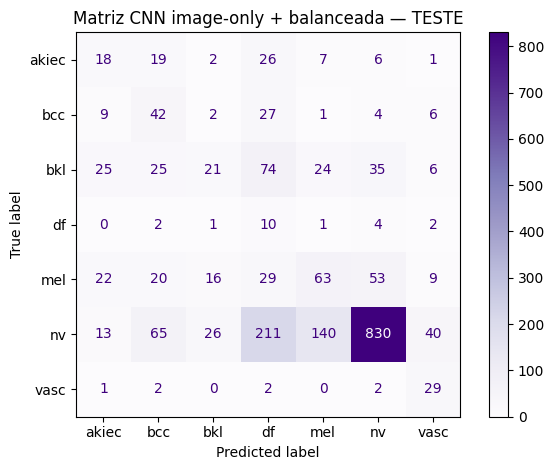

In [13]:
try:    model.load_weights('iobal_fase2.keras')
except: model.load_weights('iobal_fase1.keras')

y_true, y_pred = [], []
for Xb, yb in test_ds:
    p = model.predict(Xb, verbose=0)
    y_true.extend(np.argmax(yb.numpy(), axis=1))
    y_pred.extend(np.argmax(p, axis=1))

print("Relatorio IMAGE-ONLY + BALANCEADO (TESTE held-out por lesao):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap=plt.cm.Purples, values_format='d')
plt.title('Matriz CNN image-only + balanceada — TESTE')
plt.tight_layout(); plt.savefig('matrix_imageonly_balanced.png', dpi=150); plt.show()

In [14]:
# Embeddings das imagens ORIGINAIS UNICAS (mesmo protocolo dos demais).
extr_imgf = tf.keras.Model(model.inputs, model.get_layer("img_fused_256").output)
extr_gap  = tf.keras.Model(model.inputs, model.get_layer("image_gap").output)

def extract(paths, labels_enc):
    ds = make_img_dataset(paths, labels_enc, shuffle=False, augment=False)
    return extr_imgf.predict(ds, verbose=1), extr_gap.predict(ds, verbose=1)

f_tr, g_tr = extract(Ximg_tr, y_tr)
f_va, g_va = extract(Ximg_va, y_va)
f_te, g_te = extract(Ximg_te, y_te)
print("imgfused:", f_tr.shape, f_te.shape, "| gap:", g_tr.shape, g_te.shape)

219/219 ━━━━━━━━━━━━━━━━━━━━ 88s 344ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 76s 293ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 465ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 591ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 326ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 332ms/step
imgfused: (7006, 256) (1973, 256) | gap: (7006, 1536) (1973, 1536)


In [16]:
from google.colab import drive
drive.mount('/content/drive')
OUT = Path('/content/drive/MyDrive/ICV_imageonly_balanced_grouped')
OUT.mkdir(parents=True, exist_ok=True)
model.save(OUT / 'modelo_imageonly_balanced_grouped.keras')

def save_split(tag, f, g, y, les):
    np.save(OUT / f'X_{tag}_imgfused.npy', f)
    np.save(OUT / f'X_{tag}_gap.npy',      g)
    np.save(OUT / f'y_{tag}.npy',          np.asarray(y))
    np.save(OUT / f'lesion_{tag}.npy',     np.asarray(les))
save_split('train', f_tr, g_tr, y_tr, les_tr)
save_split('val',   f_va, g_va, y_va, les_va)
save_split('test',  f_te, g_te, y_te, les_te)

manifest = {
    "modelo": "image-only + balanceamento na origem (oversampling+aug de imagem)",
    "target_per_class_treino": int(TARGET_PER_CLASS),
    "classes": CLASS_NAMES,
    "split": {"train": int(len(train_idx)), "val": int(len(val_idx)), "test": int(len(test_idx))},
    "leakage_check": {"train_test": len(s_tr & s_te), "train_val": len(s_tr & s_va), "val_test": len(s_va & s_te)},
    "dist_teste": meta.iloc[test_idx]['dx'].value_counts().to_dict(),
    "split_method": "GroupShuffleSplit por lesion_id (70/10/20), SEED=42 — IDENTICO aos nb01/02/03",
}
(OUT / 'split_manifest_imageonly_balanced.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("Salvo em:", OUT); print(json.dumps(manifest, indent=2, ensure_ascii=False))

Mounted at /content/drive
Salvo em: /content/drive/MyDrive/ICV_imageonly_balanced_grouped
{
  "modelo": "image-only + balanceamento na origem (oversampling+aug de imagem)",
  "target_per_class_treino": 1000,
  "classes": [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
  ],
  "split": {
    "train": 7006,
    "val": 979,
    "test": 1973
  },
  "leakage_check": {
    "train_test": 0,
    "train_val": 0,
    "val_test": 0
  },
  "dist_teste": {
    "nv": 1325,
    "mel": 212,
    "bkl": 210,
    "bcc": 91,
    "akiec": 79,
    "vasc": 36,
    "df": 20
  },
  "split_method": "GroupShuffleSplit por lesion_id (70/10/20), SEED=42 — IDENTICO aos nb01/02/03"
}
